# EDA 15.3: Revenue and Inventory Constraints Analysis

This notebook analyzes whether inventory constraints such as stockouts or low fill rate appear to limit Revenue during high-demand periods, especially when traffic and promotion intensity are high.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['sales.csv', 'inventory.csv', 'products.csv', 'web_traffic.csv', 'promotions.csv', 'orders.csv', 'order_items.csv']
REQUIRED = {'sales.csv', 'inventory.csv', 'products.csv', 'web_traffic.csv', 'promotions.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
1,inventory.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\in...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,web_traffic.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\we...
4,promotions.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
5,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
6,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...


## 2. Load Sales, Inventory, Products, Traffic, Promotions, and Optional Files

Load all available inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
sales = data.get('sales')
inventory = data.get('inventory')
products = data.get('products')
web_traffic = data.get('web_traffic')
promotions = data.get('promotions')
orders = data.get('orders')
order_items = data.get('order_items')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,sales,True,3833,"Date, Revenue, COGS"
1,inventory,True,60247,"snapshot_date, product_id, stock_on_hand, unit..."
2,products,True,2412,"product_id, product_name, category, segment, s..."
3,web_traffic,True,3652,"date, sessions, unique_visitors, page_views, b..."
4,promotions,True,50,"promo_id, promo_name, promo_type, discount_val..."
5,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
6,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."


## 3. Identify Revenue, Traffic, Promotion, Inventory, Product, Category, and Date Columns

Use tolerant matching for likely naming variations. Inventory is expected to be monthly here.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue', 'amount'], contains=True),
    }

traffic_cols = {}
if web_traffic is not None:
    traffic_cols = {
        'date': find_column(web_traffic.columns, ['date', 'traffic_date'], contains=True),
        'sessions': find_column(web_traffic.columns, ['sessions']),
        'page_views': find_column(web_traffic.columns, ['page_views', 'pageviews'], contains=True),
        'unique_visitors': find_column(web_traffic.columns, ['unique_visitors', 'users', 'visitors'], contains=True),
    }

promo_cols = {}
if promotions is not None:
    promo_cols = {
        'promo_id': find_column(promotions.columns, ['promo_id', 'promotion_id', 'campaign_id'], contains=True),
        'start_date': find_column(promotions.columns, ['start_date', 'promo_start_date'], contains=True),
        'end_date': find_column(promotions.columns, ['end_date', 'promo_end_date'], contains=True),
        'discount_value': find_column(promotions.columns, ['discount_value', 'discount_amount', 'discount'], contains=True),
        'promo_type': find_column(promotions.columns, ['promo_type', 'promotion_type', 'type'], contains=True),
    }

inventory_cols = {}
if inventory is not None:
    inventory_cols = {
        'date': find_column(inventory.columns, ['snapshot_date', 'inventory_date', 'date', 'inventory_month'], contains=True),
        'product_id': find_column(inventory.columns, ['product_id']),
        'stock_qty': find_column(inventory.columns, ['stock_on_hand', 'stock_quantity', 'available_quantity', 'inventory_quantity'], contains=True),
        'stockout_flag': find_column(inventory.columns, ['stockout_flag', 'out_of_stock', 'oos_flag'], contains=True),
        'fill_rate': find_column(inventory.columns, ['fill_rate', 'availability_rate'], contains=True),
        'stockout_days': find_column(inventory.columns, ['stockout_days'], contains=True),
        'category': find_column(inventory.columns, ['category']),
        'segment': find_column(inventory.columns, ['segment']),
        'year': find_column(inventory.columns, ['year']),
        'month': find_column(inventory.columns, ['month']),
    }

product_cols = {}
if products is not None:
    product_cols = {
        'product_id': find_column(products.columns, ['product_id']),
        'category': find_column(products.columns, ['category']),
        'segment': find_column(products.columns, ['segment']),
    }

identified = pd.DataFrame({
    'sales': pd.Series(sales_cols),
    'web_traffic': pd.Series(traffic_cols),
    'promotions': pd.Series(promo_cols),
    'inventory': pd.Series(inventory_cols),
    'products': pd.Series(product_cols),
})
display(identified)

,sales,web_traffic,promotions,inventory,products
category,NaN,NaN,NaN,category,category
date,Date,date,NaN,snapshot_date,NaN
discount_value,NaN,NaN,discount_value,NaN,NaN
end_date,NaN,NaN,end_date,NaN,NaN
fill_rate,NaN,NaN,NaN,fill_rate,NaN
month,NaN,NaN,NaN,month,NaN
page_views,NaN,page_views,NaN,NaN,NaN
product_id,NaN,NaN,NaN,product_id,product_id
promo_id,NaN,NaN,promo_id,NaN,NaN
promo_type,NaN,NaN,promo_type,NaN,NaN


## 4. Prepare Daily Revenue

Standardize sales dates and Revenue, then build the daily Revenue series.

In [4]:
constraint_warnings = []
daily_revenue = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue'):
    sc = sales.copy()
    sc['date_std'] = pd.to_datetime(sc[sales_cols['date']], errors='coerce')
    sc['revenue_std'] = pd.to_numeric(sc[sales_cols['revenue']], errors='coerce')
    daily_revenue = sc.groupby('date_std').agg(Revenue=('revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})
    display(pd.DataFrame([{
        'Revenue_date_start': daily_revenue['date'].min(),
        'Revenue_date_end': daily_revenue['date'].max(),
        'missing_dates_after_agg': int(pd.date_range(daily_revenue['date'].min(), daily_revenue['date'].max(), freq='D').difference(daily_revenue['date']).size),
        'duplicate_raw_dates': int(sc.duplicated(subset=['date_std']).sum()),
        'zero_or_negative_revenue_rows': int(sc['revenue_std'].fillna(0).le(0).sum()),
    }]))
    display(sc['revenue_std'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('revenue_summary'))
else:
    warnings.warn('Daily Revenue could not be prepared from sales.csv.')

,Revenue_date_start,Revenue_date_end,missing_dates_after_agg,duplicate_raw_dates,zero_or_negative_revenue_rows
0,2012-07-04,2022-12-31,0,0,0


,revenue_summary
count,"3,833.0000"
mean,"4,286,584.0296"
std,"2,624,840.1982"
min,"279,813.9400"
25%,"2,471,088.8200"
50%,"3,647,303.9000"
75%,"5,350,877.2000"
90%,"7,685,788.5300"
95%,"9,398,759.8720"
max,"20,905,271.3500"


## 5. Prepare Traffic Data

Aggregate traffic by day and classify traffic intensity using percentile thresholds.

In [5]:
daily_traffic = pd.DataFrame()
traffic_thresholds = {}

if web_traffic is not None and traffic_cols.get('date') and traffic_cols.get('sessions'):
    wt = web_traffic.copy()
    wt['date_std'] = pd.to_datetime(wt[traffic_cols['date']], errors='coerce')
    wt['sessions_std'] = pd.to_numeric(wt[traffic_cols['sessions']], errors='coerce')
    wt['page_views_std'] = pd.to_numeric(wt[traffic_cols['page_views']], errors='coerce') if traffic_cols.get('page_views') else np.nan
    wt['unique_visitors_std'] = pd.to_numeric(wt[traffic_cols['unique_visitors']], errors='coerce') if traffic_cols.get('unique_visitors') else np.nan
    daily_traffic = wt.groupby('date_std').agg(
        sessions=('sessions_std', 'sum'),
        page_views=('page_views_std', 'sum'),
        unique_visitors=('unique_visitors_std', 'sum'),
    ).reset_index().rename(columns={'date_std': 'date'})

    hi_thr = daily_traffic['sessions'].quantile(0.75)
    lo_thr = daily_traffic['sessions'].quantile(0.25)
    traffic_thresholds = {'high': hi_thr, 'low': lo_thr}

    def traffic_group(x):
        if pd.isna(x):
            return 'unknown'
        if x >= hi_thr:
            return 'high_traffic'
        if x <= lo_thr:
            return 'low_traffic'
        return 'normal_traffic'

    daily_traffic['traffic_group'] = daily_traffic['sessions'].map(traffic_group)
    display(pd.DataFrame([{
        'traffic_date_start': daily_traffic['date'].min(),
        'traffic_date_end': daily_traffic['date'].max(),
        'high_traffic_threshold': hi_thr,
        'low_traffic_threshold': lo_thr,
        'zero_or_negative_sessions': int(daily_traffic['sessions'].fillna(0).le(0).sum()),
    }]))
    display(daily_traffic.head(10))
else:
    print('Traffic data unavailable. Traffic-specific sections will be skipped.')

,traffic_date_start,traffic_date_end,high_traffic_threshold,low_traffic_threshold,zero_or_negative_sessions
0,2013-01-01,2022-12-31,"31,782.7500","17,099.2500",0


,date,sessions,page_views,unique_visitors,traffic_group
0,2013-01-01,9760,39093,7253,low_traffic
1,2013-01-02,10456,47611,8151,low_traffic
2,2013-01-03,10076,36963,7458,low_traffic
3,2013-01-04,9973,53078,8063,low_traffic
4,2013-01-05,10223,36790,7882,low_traffic
5,2013-01-06,9545,47160,6992,low_traffic
6,2013-01-07,10203,32749,7354,low_traffic
7,2013-01-08,9456,31482,7459,low_traffic
8,2013-01-09,9162,46717,7108,low_traffic
9,2013-01-10,9887,38472,7878,low_traffic


## 6. Prepare Promotion Calendar

Expand promotion ranges into a daily active calendar with promo counts and discount intensity.

In [6]:
promo_calendar = pd.DataFrame()
promo_cov = {}

if promotions is not None and promo_cols.get('start_date') and promo_cols.get('end_date'):
    pr = promotions.copy()
    pr['promo_id_std'] = pr[promo_cols['promo_id']] if promo_cols.get('promo_id') else np.arange(len(pr))
    pr['start_date_std'] = pd.to_datetime(pr[promo_cols['start_date']], errors='coerce')
    pr['end_date_std'] = pd.to_datetime(pr[promo_cols['end_date']], errors='coerce')
    pr['discount_value_std'] = pd.to_numeric(pr[promo_cols['discount_value']], errors='coerce') if promo_cols.get('discount_value') else np.nan
    pr['promo_type_std'] = pr[promo_cols['promo_type']].astype(str).str.strip().str.lower() if promo_cols.get('promo_type') else pd.NA
    invalid_ranges = pr['start_date_std'].notna() & pr['end_date_std'].notna() & (pr['end_date_std'] < pr['start_date_std'])
    pr_valid = pr[~invalid_ranges & pr['start_date_std'].notna() & pr['end_date_std'].notna()].copy()

    expanded = []
    for row in pr_valid.itertuples():
        for dt in pd.date_range(row.start_date_std, row.end_date_std, freq='D'):
            expanded.append({
                'date': dt,
                'promo_id': row.promo_id_std,
                'discount_value': row.discount_value_std,
                'promo_type': row.promo_type_std,
            })
    promo_days = pd.DataFrame(expanded)
    if not promo_days.empty:
        promo_calendar = promo_days.groupby('date').agg(
            has_promo=('promo_id', lambda s: 1),
            active_promo_count=('promo_id', 'nunique'),
            avg_discount_value=('discount_value', 'mean'),
        ).reset_index()
        promo_cov = {'start': promo_calendar['date'].min(), 'end': promo_calendar['date'].max()}
        display(pd.DataFrame([{
            'promo_calendar_start': promo_cov['start'],
            'promo_calendar_end': promo_cov['end'],
            'promo_active_days': len(promo_calendar),
            'max_simultaneous_active_promos': promo_calendar['active_promo_count'].max(),
            'invalid_promotion_ranges': int(invalid_ranges.sum()),
        }]))
        display(promo_calendar.head(10))
    else:
        constraint_warnings.append('Promotion calendar could not be built from valid ranges')
else:
    print('Promotion calendar unavailable. Promo-specific sections will be limited.')

,promo_calendar_start,promo_calendar_end,promo_active_days,max_simultaneous_active_promos,invalid_promotion_ranges
0,2013-01-31,2022-12-31,1707,2,0


,date,has_promo,active_promo_count,avg_discount_value
0,2013-01-31,1,1,15.0000
1,2013-02-01,1,1,15.0000
2,2013-02-02,1,1,15.0000
3,2013-02-03,1,1,15.0000
4,2013-02-04,1,1,15.0000
5,2013-02-05,1,1,15.0000
6,2013-02-06,1,1,15.0000
7,2013-02-07,1,1,15.0000
8,2013-02-08,1,1,15.0000
9,2013-02-09,1,1,15.0000


## 7. Prepare Inventory Constraint Metrics

Inventory is monthly here. Aggregate month-level stockout and fill-rate signals first, then keep category-level inventory context separately.

In [7]:
inventory_monthly = pd.DataFrame()
inventory_category_monthly = pd.DataFrame()
inventory_meta = {}

if inventory is not None:
    inv = inventory.copy()
    inv['snapshot_date_std'] = pd.to_datetime(inv[inventory_cols['date']], errors='coerce') if inventory_cols.get('date') else pd.NaT
    inv['product_id_std'] = inv[inventory_cols['product_id']] if inventory_cols.get('product_id') else pd.NA
    inv['stock_qty_std'] = pd.to_numeric(inv[inventory_cols['stock_qty']], errors='coerce') if inventory_cols.get('stock_qty') else np.nan
    inv['fill_rate_std'] = pd.to_numeric(inv[inventory_cols['fill_rate']], errors='coerce') if inventory_cols.get('fill_rate') else np.nan
    inv['stockout_days_std'] = pd.to_numeric(inv[inventory_cols['stockout_days']], errors='coerce') if inventory_cols.get('stockout_days') else np.nan

    if inventory_cols.get('stockout_flag'):
        inv['stockout_flag_std'] = pd.to_numeric(inv[inventory_cols['stockout_flag']], errors='coerce').fillna(0).astype(float)
        stockout_definition = f"Existing inventory field `{inventory_cols['stockout_flag']}`"
    else:
        inv['stockout_flag_std'] = np.where(inv['stock_qty_std'].notna(), (inv['stock_qty_std'] <= 0).astype(float), np.nan)
        stockout_definition = 'Inferred as stock_on_hand <= 0'

    if ('category' not in inv.columns or inv.get('category') is None) and products is not None and product_cols.get('product_id'):
        prod = products[[product_cols['product_id'], product_cols.get('category'), product_cols.get('segment')]].copy()
        rename_map = {product_cols['product_id']: 'product_id_std'}
        if product_cols.get('category'):
            rename_map[product_cols['category']] = 'category'
        if product_cols.get('segment'):
            rename_map[product_cols['segment']] = 'segment'
        prod = prod.rename(columns=rename_map)
        inv = inv.merge(prod, on='product_id_std', how='left')

    if inventory_cols.get('category') and 'category' not in inv.columns:
        inv['category'] = inv[inventory_cols['category']]
    if inventory_cols.get('segment') and 'segment' not in inv.columns:
        inv['segment'] = inv[inventory_cols['segment']]

    inv['year_month'] = inv['snapshot_date_std'].dt.to_period('M').astype(str)
    inventory_meta = {
        'granularity': 'monthly',
        'stockout_definition': stockout_definition,
    }
    display(pd.DataFrame([inventory_meta]))

    inventory_monthly = inv.groupby('year_month').agg(
        stockout_count=('stockout_flag_std', 'sum'),
        stockout_rate=('stockout_flag_std', 'mean'),
        stockout_days_total=('stockout_days_std', 'sum'),
        avg_fill_rate=('fill_rate_std', 'mean'),
        avg_stock_qty=('stock_qty_std', 'mean'),
        product_count=('product_id_std', 'nunique'),
    ).reset_index()

    inventory_category_monthly = inv.groupby(['year_month', 'category']).agg(
        stockout_rate=('stockout_flag_std', 'mean'),
        stockout_count=('stockout_flag_std', 'sum'),
        avg_fill_rate=('fill_rate_std', 'mean'),
        product_count=('product_id_std', 'nunique'),
    ).reset_index()

    inv_quality = pd.DataFrame([{
        'missing_product_ids': int(inv['product_id_std'].isna().sum()),
        'missing_inventory_periods': int(inv['snapshot_date_std'].isna().sum()),
        'duplicate_product_period_rows': int(inv.duplicated(subset=['product_id_std', 'year_month']).sum()),
        'negative_inventory_rows': int(inv['stock_qty_std'].fillna(0).lt(0).sum()),
        'missing_fill_rate_rows': int(inv['fill_rate_std'].isna().sum()),
    }])
    display(inv_quality)
    display(inventory_monthly.head(12))
    if inv_quality.loc[0, 'negative_inventory_rows'] > 0:
        constraint_warnings.append(f"{inv_quality.loc[0, 'negative_inventory_rows']} inventory rows have negative stock")
else:
    warnings.warn('Inventory data unavailable.')

,granularity,stockout_definition
0,monthly,Existing inventory field `stockout_flag`


,missing_product_ids,missing_inventory_periods,duplicate_product_period_rows,negative_inventory_rows,missing_fill_rate_rows
0,0,0,0,0,0


,year_month,stockout_count,stockout_rate,stockout_days_total,avg_fill_rate,avg_stock_qty,product_count
0,2012-07,264.0000,0.6684,402,0.9661,59.9949,395
1,2012-08,300.0000,0.7092,699,0.9449,62.0544,423
2,2012-09,274.0000,0.6462,636,0.9500,64.9033,424
3,2012-10,282.0000,0.6453,621,0.9526,66.8055,437
4,2012-11,295.0000,0.7178,495,0.9599,73.3187,411
5,2012-12,316.0000,0.7038,666,0.9506,73.1024,449
6,2013-01,270.0000,0.6383,431,0.9660,79.3026,423
7,2013-02,315.0000,0.7111,584,0.9561,79.1332,443
8,2013-03,321.0000,0.7055,587,0.9570,80.8989,455
9,2013-04,336.0000,0.7015,674,0.9531,82.1211,479


## 8. Merge Revenue, Traffic, Promo, and Inventory Signals

Build the daily master table. Current-month inventory signals are descriptive only. Previous-month signals are the leakage-safe versions for forecasting.

In [8]:
master = pd.DataFrame()

if not daily_revenue.empty:
    master = daily_revenue.copy()
    if not daily_traffic.empty:
        master = master.merge(daily_traffic, on='date', how='left')
    if not promo_calendar.empty:
        master = master.merge(promo_calendar, on='date', how='left')
        master['has_promo_known_calendar'] = master['date'].between(promo_cov['start'], promo_cov['end'])
        for col in ['has_promo', 'active_promo_count', 'avg_discount_value']:
            if col in master.columns:
                master[col] = np.where(master['has_promo_known_calendar'], master[col].fillna(0), master[col])
    else:
        master['has_promo_known_calendar'] = False
        master['has_promo'] = np.nan
        master['active_promo_count'] = np.nan
        master['avg_discount_value'] = np.nan

    master['year_month'] = master['date'].dt.to_period('M').astype(str)
    if not inventory_monthly.empty:
        inv_current = inventory_monthly.rename(columns={
            'stockout_count': 'stockout_count_current_desc',
            'stockout_rate': 'stockout_rate_current_desc',
            'stockout_days_total': 'stockout_days_total_current_desc',
            'avg_fill_rate': 'fill_rate_current_desc',
            'avg_stock_qty': 'avg_stock_qty_current_desc',
        })
        master = master.merge(inv_current, on='year_month', how='left')

        inv_lag = inventory_monthly.copy().sort_values('year_month')
        inv_lag['stockout_lag'] = inv_lag['stockout_count'].shift(1)
        inv_lag['stockout_rate_lag_month'] = inv_lag['stockout_rate'].shift(1)
        inv_lag['fill_rate_lag_month'] = inv_lag['avg_fill_rate'].shift(1)
        inv_lag['avg_stock_qty_lag_month'] = inv_lag['avg_stock_qty'].shift(1)
        inv_lag = inv_lag[['year_month', 'stockout_lag', 'stockout_rate_lag_month', 'fill_rate_lag_month', 'avg_stock_qty_lag_month']]
        master = master.merge(inv_lag, on='year_month', how='left')

    display(master.head(15))
    print('Columns ending with `_current_desc` are descriptive current-period inventory signals only.')
    print('Lagged month inventory columns are the forecast-safe versions when future inventory status is not known in advance.')

,date,Revenue,sessions,page_views,unique_visitors,traffic_group,has_promo,active_promo_count,avg_discount_value,has_promo_known_calendar,year_month,stockout_count_current_desc,stockout_rate_current_desc,stockout_days_total_current_desc,fill_rate_current_desc,avg_stock_qty_current_desc,product_count,stockout_lag,stockout_rate_lag_month,fill_rate_lag_month,avg_stock_qty_lag_month
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2012-07,264.0000,0.6684,402,0.9661,59.9949,395,NaN,NaN,NaN,NaN


Columns ending with `_current_desc` are descriptive current-period inventory signals only.
Lagged month inventory columns are the forecast-safe versions when future inventory status is not known in advance.


## 9. Revenue vs Stockout Analysis

Compare Revenue with stockout pressure and fill rate, using month-level inventory signals merged to daily rows by year-month.

,metric,correlation
0,Revenue_vs_stockout_count,0.4361
1,Revenue_vs_stockout_rate,0.1417
2,Revenue_vs_fill_rate,-0.3121


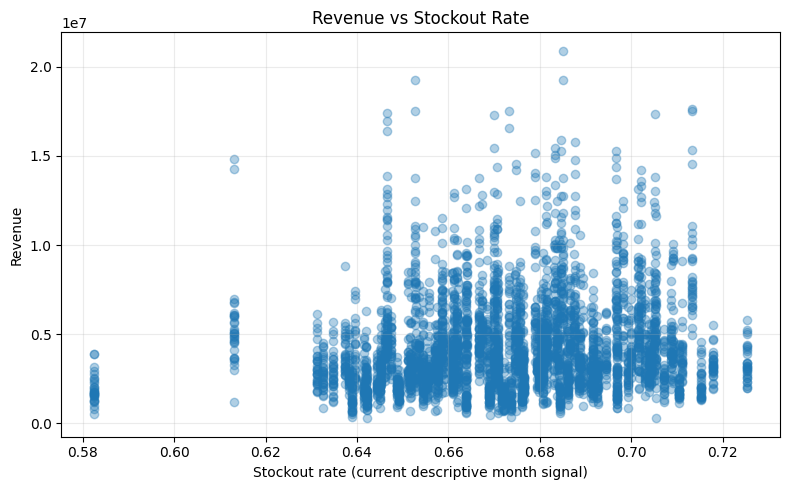

,date,Revenue,stockout_rate_current_desc,stockout_count_current_desc
241,2013-03-02,"279,813.9400",0.7055,321.0000
243,2013-03-04,"1,412,869.4300",0.7055,321.0000
521,2013-12-07,"1,444,180.4300",0.6912,329.0000
522,2013-12-08,"1,714,762.9800",0.6912,329.0000
912,2015-01-02,"1,625,420.3100",0.7070,321.0000
913,2015-01-03,"1,176,312.9400",0.7070,321.0000
916,2015-01-06,"1,621,284.6200",0.7070,321.0000
918,2015-01-08,"1,318,438.1500",0.7070,321.0000
1246,2015-12-02,"953,639.3500",0.6894,333.0000
1253,2015-12-09,"1,648,123.4100",0.6894,333.0000


In [9]:
stockout_corr = pd.DataFrame()

if not master.empty and 'stockout_rate_current_desc' in master.columns:
    corr_rows = [
        {'metric': 'Revenue_vs_stockout_count', 'correlation': master['Revenue'].corr(master['stockout_count_current_desc'])},
        {'metric': 'Revenue_vs_stockout_rate', 'correlation': master['Revenue'].corr(master['stockout_rate_current_desc'])},
    ]
    if 'fill_rate_current_desc' in master.columns:
        corr_rows.append({'metric': 'Revenue_vs_fill_rate', 'correlation': master['Revenue'].corr(master['fill_rate_current_desc'])})
    stockout_corr = pd.DataFrame(corr_rows)
    display(stockout_corr)

    fig, ax = plt.subplots(figsize=(8, 5))
    tmp = master.dropna(subset=['Revenue', 'stockout_rate_current_desc'])
    ax.scatter(tmp['stockout_rate_current_desc'], tmp['Revenue'], alpha=0.35, color='tab:blue')
    ax.set_title('Revenue vs Stockout Rate')
    ax.set_xlabel('Stockout rate (current descriptive month signal)')
    ax.set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()

    low_rev_high_stock = master[(master['Revenue'] <= master['Revenue'].quantile(0.10)) & (master['stockout_rate_current_desc'] >= master['stockout_rate_current_desc'].quantile(0.75))]
    display(low_rev_high_stock[['date', 'Revenue', 'stockout_rate_current_desc', 'stockout_count_current_desc']].head(15))

## 10. Promo Days With and Without Stockout

Compare promo periods with high stockout pressure against promo periods with lower stockout pressure.

,stockout_group,periods,avg_Revenue,median_Revenue,avg_sessions,Revenue_per_session,avg_active_promo_count
0,high_stockout,439,"4,114,734.7713","3,547,336.1600","24,990.3485",184.4836,1.0046
1,low_stockout,1268,"3,947,877.4546","3,363,506.7400","24,473.0189",168.9782,1.0142


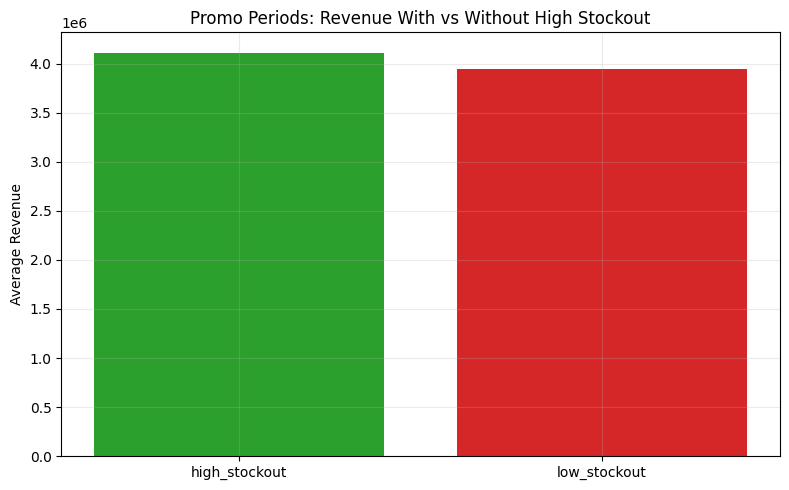

In [10]:
promo_stockout_compare = pd.DataFrame()

if not master.empty and master['has_promo_known_calendar'].any() and 'stockout_rate_current_desc' in master.columns:
    known = master[master['has_promo_known_calendar']].copy()
    stock_thr = known['stockout_rate_current_desc'].quantile(0.75)
    known['stockout_group'] = np.where(known['stockout_rate_current_desc'] >= stock_thr, 'high_stockout', 'low_stockout')
    known['Revenue_per_session'] = np.where(known['sessions'] > 0, known['Revenue'] / known['sessions'], np.nan)
    promo_stockout_compare = known[known['has_promo'] == 1].groupby('stockout_group').agg(
        periods=('date', 'size'),
        avg_Revenue=('Revenue', 'mean'),
        median_Revenue=('Revenue', 'median'),
        avg_sessions=('sessions', 'mean'),
        Revenue_per_session=('Revenue_per_session', 'mean'),
        avg_active_promo_count=('active_promo_count', 'mean'),
    ).reset_index()
    display(promo_stockout_compare)

    fig, ax = plt.subplots(figsize=(8, 5))
    ordered = promo_stockout_compare.sort_values('stockout_group')
    ax.bar(ordered['stockout_group'], ordered['avg_Revenue'], color=['tab:green', 'tab:red'])
    ax.set_title('Promo Periods: Revenue With vs Without High Stockout')
    ax.set_ylabel('Average Revenue')
    plt.tight_layout()
    plt.show()

## 11. Traffic High + Stockout High Matrix

Build a 2x2 matrix to inspect whether high-traffic/high-stockout periods underperform high-traffic/low-stockout periods.

,traffic_binary,stockout_group,periods,avg_Revenue,median_Revenue,avg_sessions,Revenue_per_session,promo_active_rate
0,high_traffic,high_stockout,286,"5,098,227.2716","4,317,138.2250","39,513.1993",133.1015,0.4336
1,high_traffic,low_stockout,627,"5,329,582.1938","4,455,488.1500","37,539.8022",144.7484,0.3461
2,low_or_normal_traffic,high_stockout,688,"4,158,065.2708","3,411,006.8300","18,971.9178",223.9664,0.4578
3,low_or_normal_traffic,low_stockout,2232,"3,929,205.4857","3,388,759.7800","21,141.8773",188.9857,0.4709


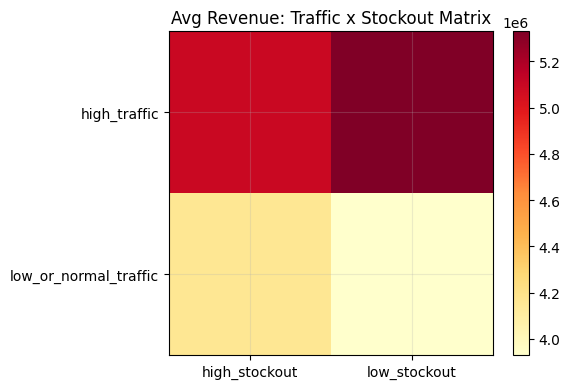

In [11]:
traffic_stockout_matrix = pd.DataFrame()

if not master.empty and 'traffic_group' in master.columns and 'stockout_rate_current_desc' in master.columns:
    stock_thr = master['stockout_rate_current_desc'].quantile(0.75)
    tmp = master.copy()
    tmp['stockout_group'] = np.where(tmp['stockout_rate_current_desc'] >= stock_thr, 'high_stockout', 'low_stockout')
    tmp['traffic_binary'] = np.where(tmp['traffic_group'] == 'high_traffic', 'high_traffic', 'low_or_normal_traffic')
    tmp['Revenue_per_session'] = np.where(tmp['sessions'] > 0, tmp['Revenue'] / tmp['sessions'], np.nan)
    if 'has_promo' in tmp.columns:
        tmp['promo_active'] = (tmp['has_promo'] == 1).astype(float)
    else:
        tmp['promo_active'] = np.nan
    traffic_stockout_matrix = tmp.groupby(['traffic_binary', 'stockout_group']).agg(
        periods=('date', 'size'),
        avg_Revenue=('Revenue', 'mean'),
        median_Revenue=('Revenue', 'median'),
        avg_sessions=('sessions', 'mean'),
        Revenue_per_session=('Revenue_per_session', 'mean'),
        promo_active_rate=('promo_active', 'mean'),
    ).reset_index()
    display(traffic_stockout_matrix)

    pivot = traffic_stockout_matrix.pivot(index='traffic_binary', columns='stockout_group', values='avg_Revenue')
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, cmap='YlOrRd')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('Avg Revenue: Traffic x Stockout Matrix')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 12. Promotion Effectiveness Under Inventory Constraints

Compare Revenue and Revenue per session across promo/non-promo and high/low stockout groups.

,promo_group,stockout_group,periods,avg_Revenue,Revenue_per_session,avg_sessions
0,non_promo,high_stockout,474,"4,821,346.7156",199.2688,"27,006.9072"
1,non_promo,low_stockout,1441,"4,513,152.8936",186.1792,"25,234.2963"
2,promo,high_stockout,439,"4,114,734.7713",184.4836,"24,990.3485"
3,promo,low_stockout,1268,"3,947,877.4546",168.9782,"24,473.0189"


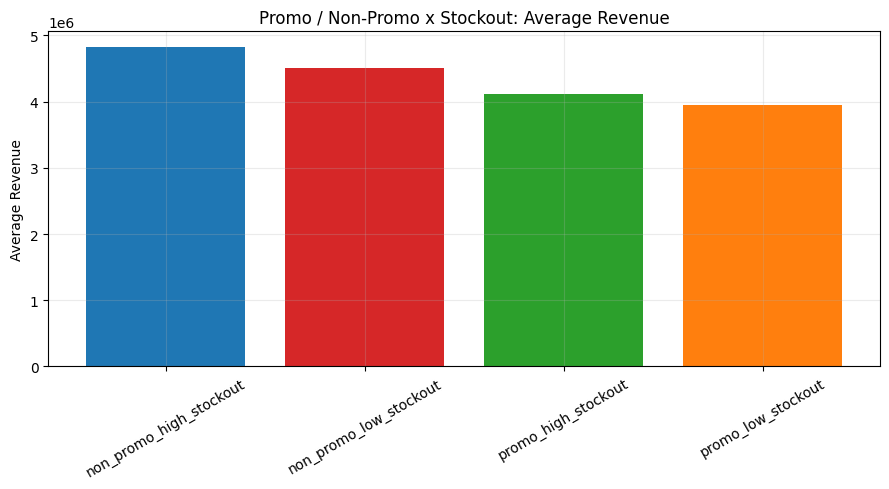

In [12]:
promo_effect_matrix = pd.DataFrame()

if not master.empty and master['has_promo_known_calendar'].any() and 'stockout_rate_current_desc' in master.columns:
    tmp = master[master['has_promo_known_calendar']].copy()
    stock_thr = tmp['stockout_rate_current_desc'].quantile(0.75)
    tmp['stockout_group'] = np.where(tmp['stockout_rate_current_desc'] >= stock_thr, 'high_stockout', 'low_stockout')
    tmp['promo_group'] = np.where(tmp['has_promo'] == 1, 'promo', 'non_promo')
    tmp['Revenue_per_session'] = np.where(tmp['sessions'] > 0, tmp['Revenue'] / tmp['sessions'], np.nan)
    promo_effect_matrix = tmp.groupby(['promo_group', 'stockout_group']).agg(
        periods=('date', 'size'),
        avg_Revenue=('Revenue', 'mean'),
        Revenue_per_session=('Revenue_per_session', 'mean'),
        avg_sessions=('sessions', 'mean'),
    ).reset_index()
    display(promo_effect_matrix)

    plot_df = promo_effect_matrix.copy()
    labels = plot_df['promo_group'] + '_' + plot_df['stockout_group']
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(labels, plot_df['avg_Revenue'], color=['tab:blue', 'tab:red', 'tab:green', 'tab:orange'])
    ax.set_title('Promo / Non-Promo x Stockout: Average Revenue')
    ax.set_ylabel('Average Revenue')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 13. Low Fill Rate and Abnormal Revenue

If fill rate is available, compare low-fill-rate periods with normal periods and inspect Revenue alignment.

,fill_group,periods,avg_Revenue,median_Revenue,avg_fill_rate
0,low_fill_rate,973,"5,595,500.8354","4,815,121.4200",0.9548
1,normal_fill_rate,2860,"3,841,277.7177","3,313,630.1050",0.9636


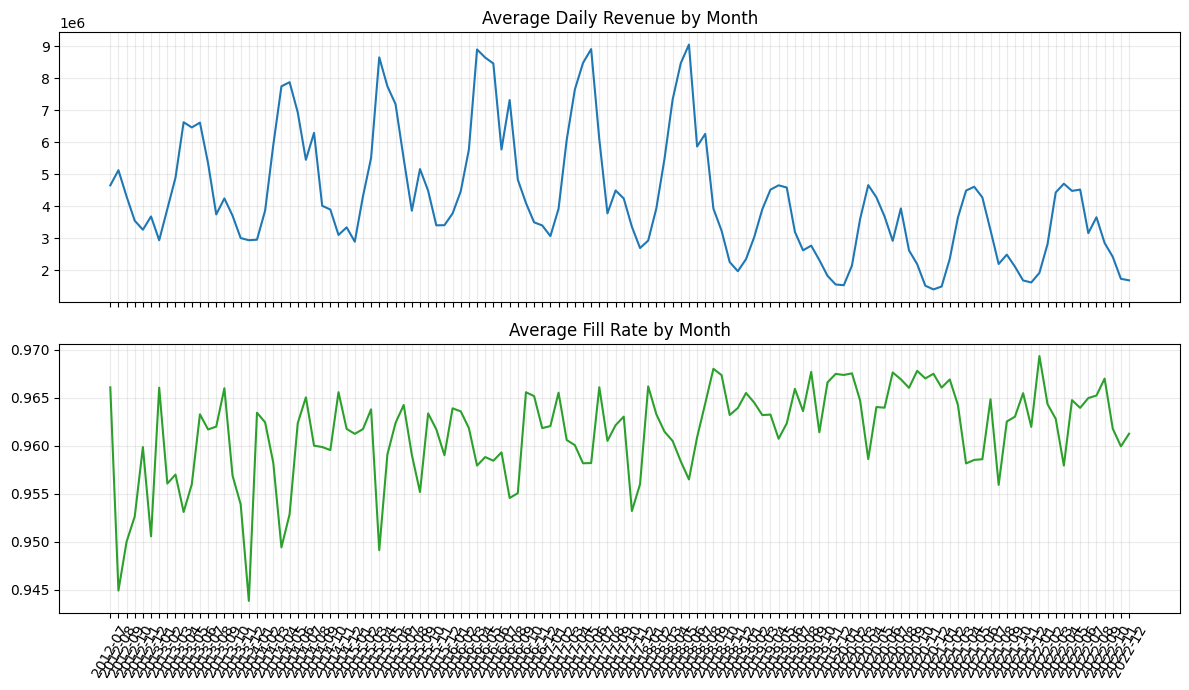

In [13]:
fill_compare = pd.DataFrame()

if not master.empty and 'fill_rate_current_desc' in master.columns and master['fill_rate_current_desc'].notna().any():
    fill_thr = master['fill_rate_current_desc'].quantile(0.25)
    tmp = master.copy()
    tmp['fill_group'] = np.where(tmp['fill_rate_current_desc'] <= fill_thr, 'low_fill_rate', 'normal_fill_rate')
    fill_compare = tmp.groupby('fill_group').agg(
        periods=('date', 'size'),
        avg_Revenue=('Revenue', 'mean'),
        median_Revenue=('Revenue', 'median'),
        avg_fill_rate=('fill_rate_current_desc', 'mean'),
    ).reset_index()
    display(fill_compare)

    if 'fill_rate_current_desc' in master.columns:
        monthly_line = master.groupby('year_month').agg(
            Revenue=('Revenue', 'mean'),
            fill_rate=('fill_rate_current_desc', 'mean')
        ).reset_index()
        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        axes[0].plot(monthly_line['year_month'], monthly_line['Revenue'], color='tab:blue')
        axes[0].set_title('Average Daily Revenue by Month')
        axes[1].plot(monthly_line['year_month'], monthly_line['fill_rate'], color='tab:green')
        axes[1].set_title('Average Fill Rate by Month')
        axes[1].tick_params(axis='x', rotation=60)
        plt.tight_layout()
        plt.show()
else:
    print('Fill-rate analysis is unavailable because fill_rate is not present.')

## 14. Category-Level Constraint Context

Use category-level monthly stockout pressure as supporting context. Category sales are optional here.

,category,avg_stockout_rate,total_stockout_count,avg_fill_rate,avg_product_count
1,GenZ,0.6857,"3,192.0000",0.9613,37.0952
3,Streetwear,0.6730,"20,883.0000",0.9605,246.1905
2,Outdoor,0.6727,"14,177.0000",0.9630,167.0635
0,Casual,0.6623,"2,319.0000",0.9623,27.8016


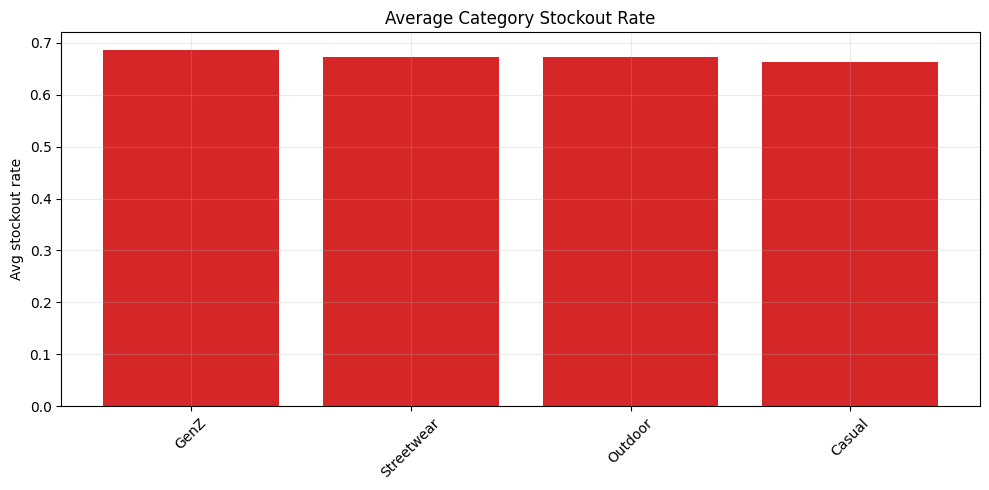

In [14]:
category_constraint = pd.DataFrame()

if not inventory_category_monthly.empty:
    category_constraint = inventory_category_monthly.groupby('category').agg(
        avg_stockout_rate=('stockout_rate', 'mean'),
        total_stockout_count=('stockout_count', 'sum'),
        avg_fill_rate=('avg_fill_rate', 'mean'),
        avg_product_count=('product_count', 'mean'),
    ).reset_index().sort_values('avg_stockout_rate', ascending=False)
    display(category_constraint)

    fig, ax = plt.subplots(figsize=(10, 5))
    top = category_constraint.head(12)
    ax.bar(top['category'].astype(str), top['avg_stockout_rate'], color='tab:red')
    ax.set_title('Average Category Stockout Rate')
    ax.set_ylabel('Avg stockout rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Category-level inventory context is unavailable.')

## 15. Interaction Feature Exploration

Create descriptive and forecast-safe interaction variables and compare their correlations with Revenue.

,feature,correlation_with_Revenue
6,sessions_lag_7_x_stockout_lag,0.3145
5,traffic_x_stockout_lag,0.3145
1,traffic_x_stockout_desc,0.2899
4,promo_x_stockout_lag,-0.1014
0,promo_x_stockout_desc,-0.0983
8,active_promo_count_known_calendar_x_stockout_lag,-0.0953
2,active_promo_count_x_stockout_desc,-0.0923
7,has_promo_known_calendar_x_stockout_lag,0.0573
3,sessions_x_promo_x_stockout_desc,-0.0296


,Revenue,sessions,has_promo,active_promo_count,stockout_rate_current_desc,fill_rate_current_desc,traffic_x_stockout_desc,promo_x_stockout_desc
Revenue,1.0000,0.3211,-0.1120,-0.1054,0.1417,-0.3121,0.2899,-0.0983
sessions,0.3211,1.0000,-0.0569,-0.0534,0.1361,-0.1148,0.9964,-0.0407
has_promo,-0.1120,-0.0569,1.0000,0.9895,-0.0313,-0.0387,-0.0595,0.9990
active_promo_count,-0.1054,-0.0534,0.9895,1.0000,-0.0349,-0.0386,-0.0563,0.9882
stockout_rate_current_desc,0.1417,0.1361,-0.0313,-0.0349,1.0000,-0.5169,0.1375,-0.0073
fill_rate_current_desc,-0.3121,-0.1148,-0.0387,-0.0386,-0.5169,1.0000,0.0492,0.0121
traffic_x_stockout_desc,0.2899,0.9964,-0.0595,-0.0563,0.1375,0.0492,1.0000,0.0632
promo_x_stockout_desc,-0.0983,-0.0407,0.9990,0.9882,-0.0073,0.0121,0.0632,1.0000


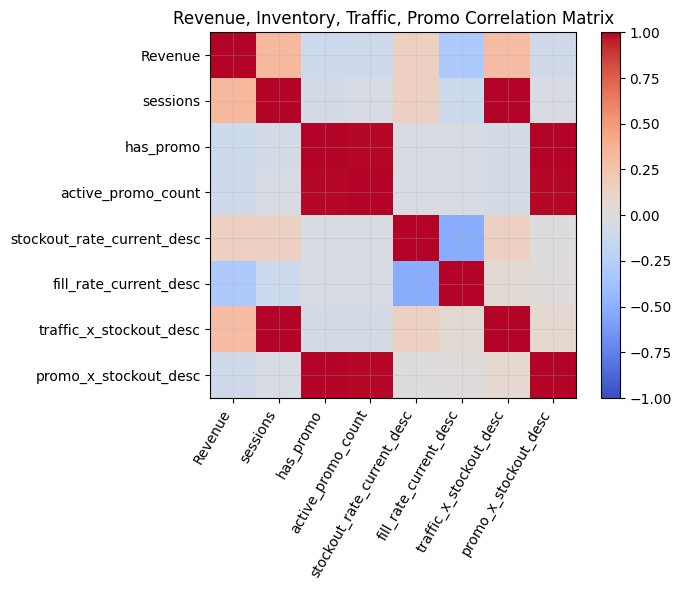

In [15]:
interaction_corr = pd.DataFrame()

if not master.empty and 'stockout_rate_current_desc' in master.columns:
    feat = master.copy()
    feat['promo_x_stockout_desc'] = feat['has_promo'].fillna(0) * feat['stockout_rate_current_desc']
    feat['traffic_x_stockout_desc'] = feat['sessions'].fillna(0) * feat['stockout_rate_current_desc']
    feat['active_promo_count_x_stockout_desc'] = feat['active_promo_count'].fillna(0) * feat['stockout_rate_current_desc']
    feat['sessions_x_promo_x_stockout_desc'] = feat['sessions'].fillna(0) * feat['has_promo'].fillna(0) * feat['stockout_rate_current_desc']

    feat['sessions_lag_1'] = feat['sessions'].shift(1) if 'sessions' in feat.columns else np.nan
    feat['sessions_lag_7'] = feat['sessions'].shift(7) if 'sessions' in feat.columns else np.nan
    feat['promo_x_stockout_lag'] = feat['has_promo'].fillna(0) * feat['stockout_rate_lag_month']
    feat['traffic_x_stockout_lag'] = feat['sessions_lag_7'] * feat['stockout_rate_lag_month']
    feat['sessions_lag_7_x_stockout_lag'] = feat['sessions_lag_7'] * feat['stockout_rate_lag_month']
    feat['has_promo_known_calendar_x_stockout_lag'] = feat['has_promo_known_calendar'].astype(float) * feat['stockout_rate_lag_month']
    feat['active_promo_count_known_calendar_x_stockout_lag'] = feat['active_promo_count'].fillna(0) * feat['stockout_rate_lag_month']

    interaction_rows = []
    for col in [
        'promo_x_stockout_desc', 'traffic_x_stockout_desc', 'active_promo_count_x_stockout_desc',
        'sessions_x_promo_x_stockout_desc', 'promo_x_stockout_lag', 'traffic_x_stockout_lag',
        'sessions_lag_7_x_stockout_lag', 'has_promo_known_calendar_x_stockout_lag',
        'active_promo_count_known_calendar_x_stockout_lag'
    ]:
        interaction_rows.append({'feature': col, 'correlation_with_Revenue': feat['Revenue'].corr(feat[col])})
    interaction_corr = pd.DataFrame(interaction_rows).sort_values('correlation_with_Revenue', ascending=False, key=lambda s: s.abs())
    display(interaction_corr)

    numeric_cols = ['Revenue']
    for c in ['sessions', 'has_promo', 'active_promo_count', 'stockout_rate_current_desc', 'fill_rate_current_desc', 'traffic_x_stockout_desc', 'promo_x_stockout_desc']:
        if c in feat.columns:
            numeric_cols.append(c)
    corr_matrix = feat[numeric_cols].corr()
    display(corr_matrix)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=60, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title('Revenue, Inventory, Traffic, Promo Correlation Matrix')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 16. Leakage-Safe Inventory-Constraint Feature Preview

Create daily candidate features using lagged inventory signals and lagged traffic, with promo calendar features included only when the calendar is known in advance.

In [16]:
feature_preview = pd.DataFrame()

if not master.empty:
    feat = master.sort_values('date').copy()
    feat['sessions_lag_1'] = feat['sessions'].shift(1) if 'sessions' in feat.columns else np.nan
    feat['sessions_lag_7'] = feat['sessions'].shift(7) if 'sessions' in feat.columns else np.nan
    feat['stockout_rate'] = feat['stockout_rate_current_desc']
    feat['fill_rate'] = feat['fill_rate_current_desc'] if 'fill_rate_current_desc' in feat.columns else np.nan
    feat['promo_x_stockout_lag'] = feat['has_promo'].fillna(0) * feat['stockout_rate_lag_month']
    feat['traffic_x_stockout_lag'] = feat['sessions_lag_7'] * feat['stockout_rate_lag_month']
    feat['sessions_lag_7_x_stockout_lag'] = feat['sessions_lag_7'] * feat['stockout_rate_lag_month']
    feat['has_promo_known_calendar_x_stockout_lag'] = feat['has_promo_known_calendar'].astype(float) * feat['stockout_rate_lag_month']
    feat['active_promo_count_x_stockout_lag'] = feat['active_promo_count'].fillna(0) * feat['stockout_rate_lag_month']

    preview_cols = ['date', 'Revenue']
    for col in ['sessions', 'has_promo', 'active_promo_count', 'stockout_rate', 'fill_rate', 'stockout_lag', 'stockout_rate_lag_month', 'fill_rate_lag_month', 'sessions_lag_1', 'sessions_lag_7', 'promo_x_stockout_lag', 'traffic_x_stockout_lag', 'sessions_lag_7_x_stockout_lag', 'has_promo_known_calendar_x_stockout_lag', 'active_promo_count_x_stockout_lag']:
        if col in feat.columns:
            preview_cols.append(col)
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('Forecast-safe inventory interactions require every component to be valid at prediction time.')
print('If inventory is monthly and future month status is unknown, use lagged month inventory signals only.')
print('If future traffic is unknown, use lagged traffic or separately forecast traffic before forming interactions.')
print('If future promo calendar is unknown, promo interaction terms are not valid for future dates.')

,date,Revenue,sessions,has_promo,active_promo_count,stockout_rate,fill_rate,stockout_lag,stockout_rate_lag_month,fill_rate_lag_month,sessions_lag_1,sessions_lag_7,promo_x_stockout_lag,traffic_x_stockout_lag,sessions_lag_7_x_stockout_lag,has_promo_known_calendar_x_stockout_lag,active_promo_count_x_stockout_lag
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,0.6684,0.9661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Forecast-safe inventory interactions require every component to be valid at prediction time.
If inventory is monthly and future month status is unknown, use lagged month inventory signals only.
If future traffic is unknown, use lagged traffic or separately forecast traffic before forming interactions.
If future promo calendar is unknown, promo interaction terms are not valid for future dates.


## 17. Key Observations and Warnings

Summarize whether stockout pressure appears to constrain Revenue and whether traffic or promotions behave differently under higher inventory pressure.

In [17]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not stockout_corr.empty:
    rev_stock = stockout_corr.loc[stockout_corr['metric'] == 'Revenue_vs_stockout_rate', 'correlation']
    if not rev_stock.empty:
        relation = 'lower' if rev_stock.iloc[0] < -0.05 else 'higher' if rev_stock.iloc[0] > 0.05 else 'mixed'
        summary_lines.append(f'- High stockout pressure appears associated with {relation} Revenue under simple stockout-rate correlation ({rev_stock.iloc[0]:.4f}).')

if not promo_stockout_compare.empty:
    hi = promo_stockout_compare.loc[promo_stockout_compare['stockout_group'] == 'high_stockout', 'avg_Revenue']
    lo = promo_stockout_compare.loc[promo_stockout_compare['stockout_group'] == 'low_stockout', 'avg_Revenue']
    if not hi.empty and not lo.empty:
        weaker = 'weaker' if hi.iloc[0] < lo.iloc[0] else 'stronger'
        summary_lines.append(f'- Promo periods with stockout pressure appear {weaker} than promo periods without high stockout ({hi.iloc[0]:,.2f} vs {lo.iloc[0]:,.2f}).')

if not traffic_stockout_matrix.empty:
    hi_hi = traffic_stockout_matrix[(traffic_stockout_matrix['traffic_binary'] == 'high_traffic') & (traffic_stockout_matrix['stockout_group'] == 'high_stockout')]
    hi_lo = traffic_stockout_matrix[(traffic_stockout_matrix['traffic_binary'] == 'high_traffic') & (traffic_stockout_matrix['stockout_group'] == 'low_stockout')]
    if not hi_hi.empty and not hi_lo.empty:
        under = 'underperform' if hi_hi['avg_Revenue'].iloc[0] < hi_lo['avg_Revenue'].iloc[0] else 'do not underperform'
        summary_lines.append(f"- High traffic + high stockout periods {under} high traffic + low stockout periods ({hi_hi['avg_Revenue'].iloc[0]:,.2f} vs {hi_lo['avg_Revenue'].iloc[0]:,.2f}).")

if not fill_compare.empty:
    low_fill = fill_compare.loc[fill_compare['fill_group'] == 'low_fill_rate', 'avg_Revenue']
    normal_fill = fill_compare.loc[fill_compare['fill_group'] == 'normal_fill_rate', 'avg_Revenue']
    if not low_fill.empty and not normal_fill.empty:
        summary_lines.append(f'- Low fill rate aligns with {"lower" if low_fill.iloc[0] < normal_fill.iloc[0] else "higher"} average Revenue ({low_fill.iloc[0]:,.2f} vs {normal_fill.iloc[0]:,.2f}).')

if not category_constraint.empty:
    top_cat = category_constraint.head(3)
    summary_lines.append('- Categories with high inventory constraint pressure: ' + ', '.join(f"{r.category} ({r.avg_stockout_rate:.2%})" for r in top_cat.itertuples()) + '.')

if not interaction_corr.empty:
    top_features = interaction_corr.head(5)
    summary_lines.append('- Strongest candidate interaction features: ' + ', '.join(f"{r.feature} ({r.correlation_with_Revenue:.4f})" for r in top_features.itertuples()) + '.')

if constraint_warnings:
    summary_lines.append('- Data quality warnings related to inventory, traffic, promotions, and Revenue: ' + '; '.join(constraint_warnings))
else:
    summary_lines.append('- Data quality warnings related to inventory, traffic, promotions, and Revenue: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe stockout/promo/traffic interaction features: stockout_lag, stockout_rate_lag_month, fill_rate_lag_month, sessions_lag_1, sessions_lag_7, promo_x_stockout_lag, traffic_x_stockout_lag, sessions_lag_7_x_stockout_lag, has_promo_known_calendar_x_stockout_lag, and active_promo_count_x_stockout_lag.')
summary_lines.append('- Interaction features are valid only when every component is valid at prediction time. Future traffic must be known or forecasted, future promo calendar must be known, and future inventory status must be known or replaced with lagged inventory signals.')
summary_lines.append('- Causal caution: this is observational EDA. Revenue suppression signals can reflect seasonality, product mix, campaign targeting, and operational timing as well as inventory constraints.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- High stockout pressure appears associated with higher Revenue under simple stockout-rate correlation (0.1417).
- Promo periods with stockout pressure appear stronger than promo periods without high stockout (4,114,734.77 vs 3,947,877.45).
- High traffic + high stockout periods underperform high traffic + low stockout periods (5,098,227.27 vs 5,329,582.19).
- Low fill rate aligns with higher average Revenue (5,595,500.84 vs 3,841,277.72).
- Categories with high inventory constraint pressure: GenZ (68.57%), Streetwear (67.30%), Outdoor (67.27%).
- Strongest candidate interaction features: sessions_lag_7_x_stockout_lag (0.3145), traffic_x_stockout_lag (0.3145), traffic_x_stockout_desc (0.2899), promo_x_stockout_lag (-0.1014), promo_x_stockout_desc (-0.0983).
- Data quality warnings related to inventory, traffic, promotions, and Revenue: none beyond the checks reported in notebook tables.
- Recommended leakage-safe stockout/promo/traffic interaction features